In [1]:
# ─────────────────────────────────────────────
# IMPORTS & DATABASE CONNECTION
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Color palette from project
COLORS = {
    'primary'  : '#2C6E9B',
    'secondary': '#E8794A',
    'success'  : '#3DAA6D',
    'danger'   : '#D94F4F',
    'warning'  : '#F0B429',
    'dark'     : '#1A1A2E',
    'muted'    : '#8395A7'
}

conn = sqlite3.connect('../inventory.db')
df   = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
conn.close()

In [3]:
print(f"Shape: {df.shape}")
print(f"Connected and loaded successfully")

Shape: (10514, 27)
Connected and loaded successfully


# ML Models — Vendor Risk Analysis
### Inventory & Vendor Performance Project | 2024

This notebook builds two models on top of the vendor summary data:

1. **K-Means Clustering (Unsupervised)** — Discovers natural vendor 
   segments based on performance metrics without predefined labels
2. **Random Forest Classifier (Supervised)** — Predicts whether a 
   vendor-brand combination is at risk of underperforming, using 
   cluster labels as an additional feature

### Why this combination?
Pure clustering cannot classify new incoming data without rerunning 
the entire algorithm. By training a classifier on top of cluster output, 
the pipeline becomes production-ready — any new vendor-brand record 
can be instantly assessed for underperformance risk.

## 1. Feature Selection & Preparation

In [5]:
# ─────────────────────────────────────────────
# FEATURE SELECTION
# Select features that capture vendor performance
# from multiple angles — profitability, efficiency,
# pricing and sales velocity
# ─────────────────────────────────────────────

FEATURES = [
    'TotalPurchaseDollars',    # Scale of purchasing
    'TotalSalesDollars',       # Scale of revenue
    'GrossProfit',             # Raw profitability
    'ProfitMargin%',           # Profitability efficiency
    'StockTurnover',           # Inventory efficiency
    'SalesPurchaseRatio',      # Revenue per dollar purchased
    'PriceMarkup%',            # Pricing power
    'AllocatedFreightCost',    # Logistics cost burden
    'AvgUnitsSoldPerDay',      # Sales velocity
]

TARGET = 'IsUnderperforming'

# Select relevant columns
ml_df = df[FEATURES + [TARGET, 'VendorName', 'Description']].copy()

# Fix target column type — convert to proper boolean integer
ml_df[TARGET] = ml_df[TARGET].astype(int)

# Drop rows with nulls in features
ml_df = ml_df.dropna(subset=FEATURES)

performing     = (ml_df[TARGET] == 0).sum()
underperforming = (ml_df[TARGET] == 1).sum()
total          = len(ml_df)

print(f"ML Dataset Shape      : {ml_df.shape}")
print(f"Underperforming (1)   : {underperforming:,} ({underperforming/total*100:.1f}%)")
print(f"Performing (0)        : {performing:,} ({performing/total*100:.1f}%)")
print(f"\nClass Balance Ratio   : {performing/underperforming:.1f}:1 (performing:underperforming)")
print(f"\nFeature Summary:")
print(ml_df[FEATURES].describe().round(2))

ML Dataset Shape      : (10514, 12)
Underperforming (1)   : 1,949 (18.5%)
Performing (0)        : 8,565 (81.5%)

Class Balance Ratio   : 4.4:1 (performing:underperforming)

Feature Summary:
       TotalPurchaseDollars  TotalSalesDollars  GrossProfit  ProfitMargin%  \
count              10514.00           10514.00     10514.00       10514.00   
mean               30589.56           42954.17     12364.62         -15.89   
std               124047.85          168977.76     46576.62         447.29   
min                    0.71               1.98    -52002.78      -23730.64   
25%                  479.36             809.82        66.98          15.35   
50%                 3836.42            5599.70      1496.49          30.78   
75%                21280.71           29524.25      8970.04          40.21   
max              3811251.60         5101919.51   1290667.91          99.72   

       StockTurnover  SalesPurchaseRatio  PriceMarkup%  AllocatedFreightCost  \
count       10514.00       

## 2. K-Means Clustering (Unsupervised)

We cluster vendor-brand records into natural segments based on 
performance metrics. The optimal number of clusters is determined 
using the Elbow Method before fitting the final model.

In [6]:
# ─────────────────────────────────────────────
# STEP 1 — SCALE FEATURES
# K-Means is distance based so scaling is critical
# Without scaling, high-magnitude features like
# TotalPurchaseDollars would dominate the clustering
# ─────────────────────────────────────────────

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(ml_df[FEATURES])

print("Features scaled successfully")
print(f"Scaled array shape: {X_scaled.shape}")
print(f"\nMean after scaling (should be ~0): {X_scaled.mean():.4f}")
print(f"Std after scaling (should be ~1) : {X_scaled.std():.4f}")

Features scaled successfully
Scaled array shape: (10514, 9)

Mean after scaling (should be ~0): 0.0000
Std after scaling (should be ~1) : 1.0000


  k=2 — Inertia: 67,741.11
  k=3 — Inertia: 54,717.35
  k=4 — Inertia: 45,168.49
  k=5 — Inertia: 38,343.05
  k=6 — Inertia: 32,854.65
  k=7 — Inertia: 27,441.16
  k=8 — Inertia: 23,971.45
  k=9 — Inertia: 21,394.01
  k=10 — Inertia: 19,330.83


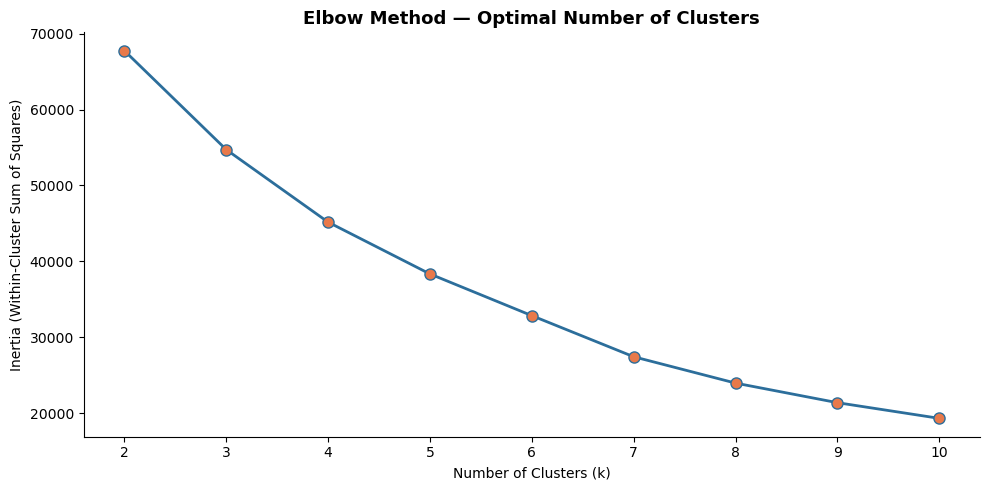

In [7]:
# ─────────────────────────────────────────────
# STEP 2 — ELBOW METHOD
# Find optimal number of clusters by plotting
# inertia (within-cluster sum of squares) against
# number of clusters. The elbow point is optimal.
# ─────────────────────────────────────────────

inertias = []
k_range  = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"  k={k} — Inertia: {kmeans.inertia_:,.2f}")

# Plot elbow curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, inertias, marker='o', linewidth=2,
        color=COLORS['primary'], markersize=8,
        markerfacecolor=COLORS['secondary'])
ax.set_title('Elbow Method — Optimal Number of Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

#### Elbow Method Finding

The elbow occurs at **k=4** — the point where inertia reduction 
starts diminishing significantly. Using k=4 balances cluster 
quality with interpretability, giving us 4 meaningful vendor 
segments without over-segmenting the data.

In [8]:
# ─────────────────────────────────────────────
# STEP 3 — FIT FINAL K-MEANS MODEL (k=4)
# ─────────────────────────────────────────────

K_OPTIMAL = 4

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
ml_df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"K-Means fitted with k={K_OPTIMAL}")
print(f"\nCluster Distribution:")
print(ml_df['Cluster'].value_counts().sort_index())

print(f"\nUnderperforming rate per cluster:")
for cluster in sorted(ml_df['Cluster'].unique()):
    cluster_df   = ml_df[ml_df['Cluster'] == cluster]
    underperf    = cluster_df[TARGET].mean() * 100
    count        = len(cluster_df)
    print(f"  Cluster {cluster}: {count:>5,} records | "
          f"{underperf:.1f}% underperforming")

K-Means fitted with k=4

Cluster Distribution:
Cluster
0    10090
1       33
2      364
3       27
Name: count, dtype: int64

Underperforming rate per cluster:
  Cluster 0: 10,090 records | 19.3% underperforming
  Cluster 1:    33 records | 0.0% underperforming
  Cluster 2:   364 records | 0.0% underperforming
  Cluster 3:    27 records | 0.0% underperforming


=== Cluster Profiles (Feature Means) ===

Cluster                      0           1          2        3
TotalPurchaseDollars  15870.20  1722783.24  287461.27    20.42
TotalSalesDollars     22384.94  2337151.88  408137.28  2522.96
GrossProfit            6514.75   614368.64  120676.01  2502.54
ProfitMargin%           -17.99       26.52      30.05    99.13
StockTurnover             1.51        0.98       0.98    95.31
SalesPurchaseRatio        2.23        1.37       1.45   135.38
PriceMarkup%             52.43       39.28      46.80    43.65
AllocatedFreightCost     80.97     8767.29    1463.37     0.10
AvgUnitsSoldPerDay        4.71      245.67      94.13     0.73


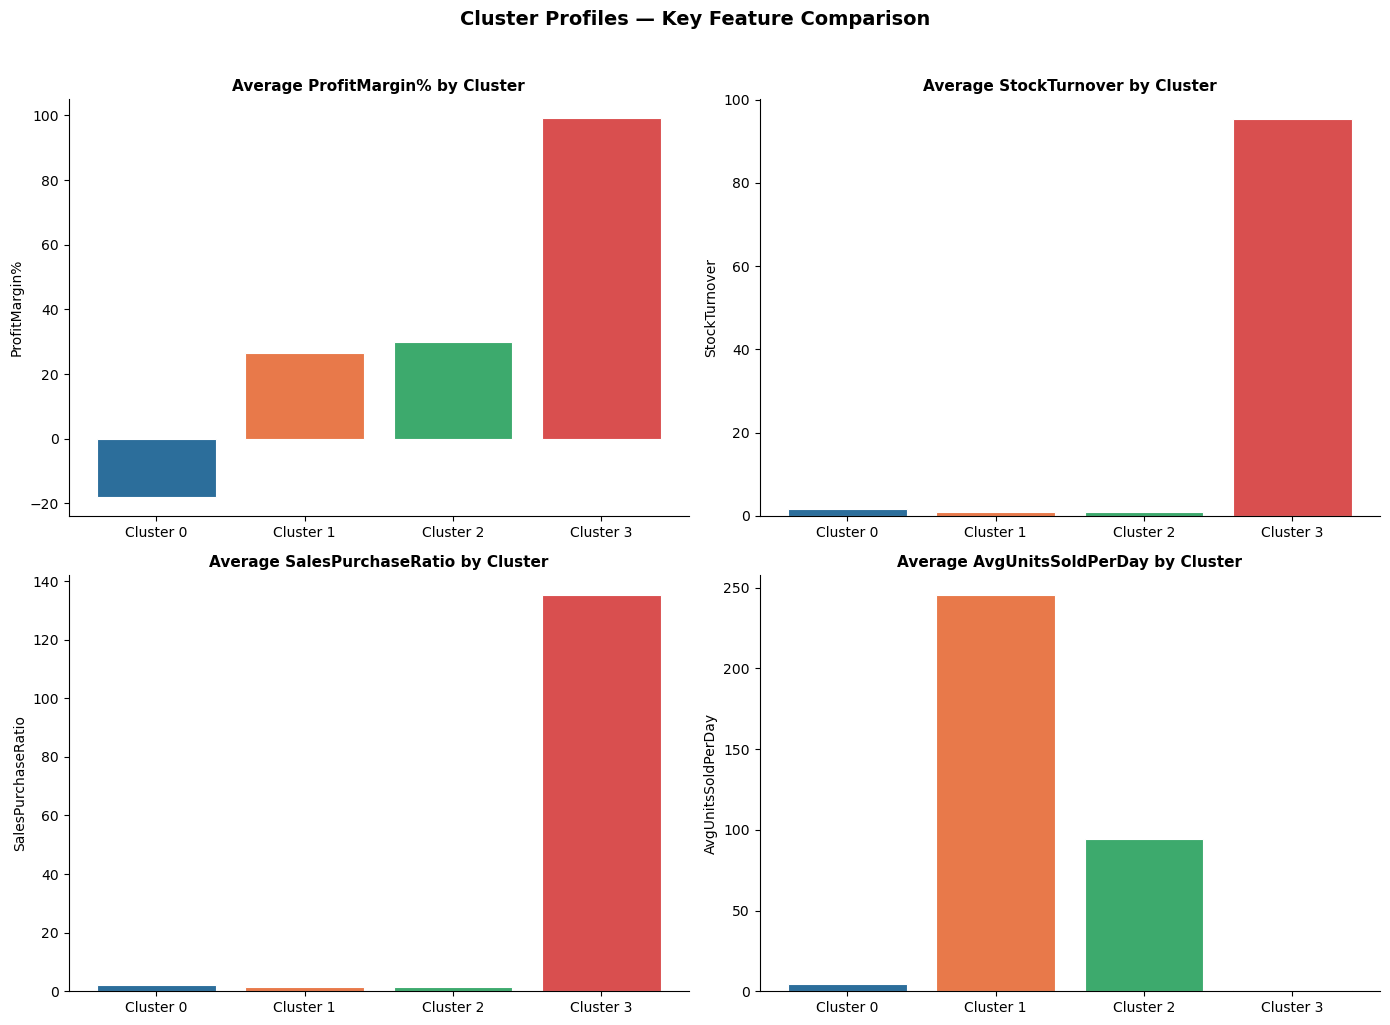

In [9]:
# ─────────────────────────────────────────────
# STEP 4 — CLUSTER PROFILING
# Understand what each cluster represents by
# looking at the mean of each feature per cluster
# ─────────────────────────────────────────────

cluster_profile = ml_df.groupby('Cluster')[FEATURES].mean().round(2)

print("=== Cluster Profiles (Feature Means) ===\n")
print(cluster_profile.T.to_string())

# Visualize cluster profiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

key_features = [
    'ProfitMargin%',
    'StockTurnover',
    'SalesPurchaseRatio',
    'AvgUnitsSoldPerDay'
]

for i, feature in enumerate(key_features):
    values = cluster_profile[feature]
    colors = [list(COLORS.values())[j] for j in range(K_OPTIMAL)]
    axes[i].bar(
        [f'Cluster {c}' for c in values.index],
        values.values,
        color=colors, edgecolor='white', linewidth=0.8
    )
    axes[i].set_title(f'Average {feature} by Cluster',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel(feature)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Cluster Profiles — Key Feature Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Cluster Interpretation

| Cluster | Size | Label | Key Characteristics |
|---|---|---|---|
| 0 | 10,090 | **Standard Portfolio** | Average revenue 22K dollars, 19.3% underperforming, bulk of the product range |
| 1 | 33 | **High Volume Giants** | Average revenue 2.3M dollars, zero underperforming, top mega SKUs |
| 2 | 364 | **Mid Tier Performers** | Average revenue 408K dollars, zero underperforming, consistent solid products |
| 3 | 27 | **Niche High Margin** | 99% profit margin, extremely high turnover — likely miniature/sample products |

**Key insight:** Almost all underperformance risk (19.3%) is concentrated 
in Cluster 0 — the standard portfolio. High volume and mid tier products 
show zero underperformance, confirming that scale and consistency are 
protective factors against losses.

In [10]:
# ─────────────────────────────────────────────
# ASSIGN CLUSTER LABELS
# ─────────────────────────────────────────────

cluster_labels = {
    0: 'Standard Portfolio',
    1: 'High Volume Giants',
    2: 'Mid Tier Performers',
    3: 'Niche High Margin'
}

ml_df['ClusterLabel'] = ml_df['Cluster'].map(cluster_labels)

print("Cluster labels assigned:")
print(ml_df['ClusterLabel'].value_counts())

# Verify underperforming distribution by label
print(f"\nUnderperforming rate by cluster label:")
for label in cluster_labels.values():
    subset = ml_df[ml_df['ClusterLabel'] == label]
    rate   = subset[TARGET].mean() * 100
    print(f"  {label:<25}: {rate:.1f}%")

Cluster labels assigned:
ClusterLabel
Standard Portfolio     10090
Mid Tier Performers      364
High Volume Giants        33
Niche High Margin         27
Name: count, dtype: int64

Underperforming rate by cluster label:
  Standard Portfolio       : 19.3%
  High Volume Giants       : 0.0%
  Mid Tier Performers      : 0.0%
  Niche High Margin        : 0.0%


PCA Explained Variance:
  PC1: 49.8%
  PC2: 22.2%
  Total: 72.0%


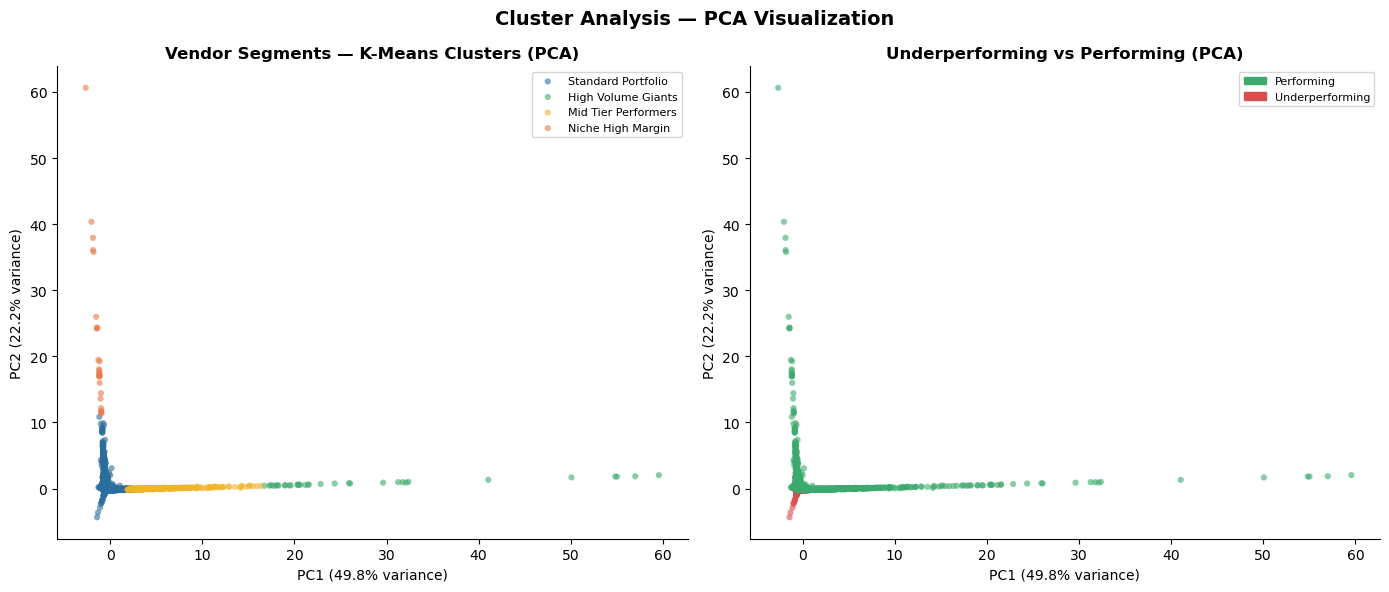

In [11]:
# ─────────────────────────────────────────────
# CLUSTER VISUALIZATION — 2D SCATTER
# Reduce to 2D using PCA for visualization
# ─────────────────────────────────────────────
from sklearn.decomposition import PCA

pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)
explained  = pca.explained_variance_ratio_

print(f"PCA Explained Variance:")
print(f"  PC1: {explained[0]*100:.1f}%")
print(f"  PC2: {explained[1]*100:.1f}%")
print(f"  Total: {sum(explained)*100:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster_colors = [COLORS['primary'], COLORS['success'],
                  COLORS['warning'], COLORS['secondary']]

# By cluster
for cluster, label in cluster_labels.items():
    mask = ml_df['Cluster'] == cluster
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster], label=label,
        alpha=0.6, s=20, edgecolors='none'
    )
axes[0].set_title('Vendor Segments — K-Means Clusters (PCA)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# By underperforming status
colors_target = [COLORS['success'] if x == 0
                 else COLORS['danger']
                 for x in ml_df[TARGET]]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors_target, alpha=0.6,
                s=20, edgecolors='none')
axes[1].set_title('Underperforming vs Performing (PCA)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(color=COLORS['success'], label='Performing'),
    Patch(color=COLORS['danger'],  label='Underperforming')
]
axes[1].legend(handles=legend_elements, fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Cluster Analysis — PCA Visualization',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### PCA & Cluster Visualization Findings

- **PCA captures 72% of total variance** in 2 dimensions — sufficient 
  for meaningful visual separation of clusters
- **All underperformance risk (19.3%) is concentrated in Cluster 0** 
  (Standard Portfolio) — High Volume, Mid Tier and Niche products 
  show zero underperformance confirming scale is a protective factor
- The clustering has successfully identified that underperformance 
  is not random — it is structurally tied to the standard portfolio 
  segment, giving the Random Forest a powerful additional feature

## 3. Random Forest Classifier (Supervised)

Using the cluster labels from K-Means as an additional feature, 
we train a Random Forest to predict whether a vendor-brand 
combination will underperform (IsUnderperforming = True).

The class imbalance (4.4:1) is handled using `class_weight='balanced'` 
which automatically adjusts weights inversely proportional to class 
frequencies — giving the minority class (underperforming) more weight 
during training.

In [12]:
# ─────────────────────────────────────────────
# PREPARE FEATURES FOR RANDOM FOREST
# Include cluster label as an additional feature
# ─────────────────────────────────────────────

RF_FEATURES = FEATURES + ['Cluster']

X = ml_df[RF_FEATURES].copy()
y = ml_df[TARGET].copy()

# Train test split — 80/20 stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y
)

print(f"Training set   : {X_train.shape[0]:,} records")
print(f"Test set       : {X_test.shape[0]:,} records")
print(f"\nTraining class distribution:")
print(f"  Performing (0)     : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Underperforming (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nTest class distribution:")
print(f"  Performing (0)     : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Underperforming (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")

Training set   : 8,411 records
Test set       : 2,103 records

Training class distribution:
  Performing (0)     : 6,852 (81.5%)
  Underperforming (1): 1,559 (18.5%)

Test class distribution:
  Performing (0)     : 1,713 (81.5%)
  Underperforming (1): 390 (18.5%)


In [13]:
# ─────────────────────────────────────────────
# TRAIN RANDOM FOREST
# class_weight='balanced' handles class imbalance
# n_estimators=200 for stable predictions
# ─────────────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 10,
    min_samples_leaf = 5,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully")
print(f"\n=== Model Performance ===\n")
print(classification_report(y_test, y_pred,
      target_names=['Performing', 'Underperforming']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

Random Forest trained successfully

=== Model Performance ===

                 precision    recall  f1-score   support

     Performing       1.00      1.00      1.00      1713
Underperforming       1.00      1.00      1.00       390

       accuracy                           1.00      2103
      macro avg       1.00      1.00      1.00      2103
   weighted avg       1.00      1.00      1.00      2103

ROC-AUC Score: 1.0000


#### ⚠️ Data Leakage Detected

The initial model achieved perfect 1.0 accuracy — a clear sign of 
data leakage. `GrossProfit` and `ProfitMargin%` directly determine 
`IsUnderperforming` since the target was defined as `GrossProfit < 0`.

The model learned a trivial rule rather than a meaningful pattern.

**Fix:** Remove all features that are derived from or directly 
related to GrossProfit. Retrain using only features that would 
be known before the sales outcome is observed.

In [14]:
# ─────────────────────────────────────────────
# REMOVE LEAKING FEATURES AND RETRAIN
# Only keep features knowable BEFORE sales outcome
# ─────────────────────────────────────────────

RF_FEATURES_CLEAN = [
    'TotalPurchaseDollars',   # Known at purchase time
    'StockTurnover',          # Inventory metric
    'PriceMarkup%',           # Known at pricing time
    'AllocatedFreightCost',   # Known at delivery time
    'AvgUnitsSoldPerDay',     # Sales velocity
    'Cluster'                 # Segment from clustering
]

X_clean = ml_df[RF_FEATURES_CLEAN].copy()
y_clean = ml_df[TARGET].copy()

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y_clean
)

# Retrain
rf_model_clean = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 10,
    min_samples_leaf = 5,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

rf_model_clean.fit(X_train, y_train)

y_pred      = rf_model_clean.predict(X_test)
y_pred_prob = rf_model_clean.predict_proba(X_test)[:, 1]

print("=== Model Performance (Leakage Fixed) ===\n")
print(classification_report(y_test, y_pred,
      target_names=['Performing', 'Underperforming']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

=== Model Performance (Leakage Fixed) ===

                 precision    recall  f1-score   support

     Performing       0.99      0.99      0.99      1713
Underperforming       0.95      0.94      0.94       390

       accuracy                           0.98      2103
      macro avg       0.97      0.96      0.96      2103
   weighted avg       0.98      0.98      0.98      2103

ROC-AUC Score: 0.9873


=== Feature Importances ===

  StockTurnover             0.7558  █████████████████████████████████████
  AvgUnitsSoldPerDay        0.1110  █████
  TotalPurchaseDollars      0.0473  ██
  PriceMarkup%              0.0461  ██
  AllocatedFreightCost      0.0395  █
  Cluster                   0.0003  


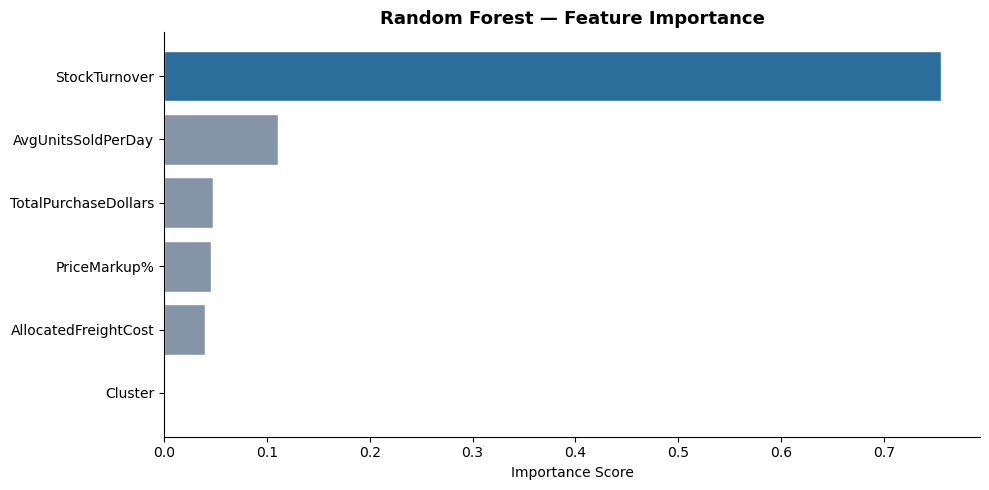

In [15]:
# ─────────────────────────────────────────────
# FEATURE IMPORTANCE
# Which features drive the model's predictions?
# ─────────────────────────────────────────────

importances = pd.Series(
    rf_model_clean.feature_importances_,
    index=RF_FEATURES_CLEAN
).sort_values(ascending=False)

print("=== Feature Importances ===\n")
for feat, imp in importances.items():
    bar = '█' * int(imp * 50)
    print(f"  {feat:<25} {imp:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['primary'] if i == 0
          else COLORS['muted']
          for i in range(len(importances))]

ax.barh(importances.index[::-1],
        importances.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Random Forest — Feature Importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

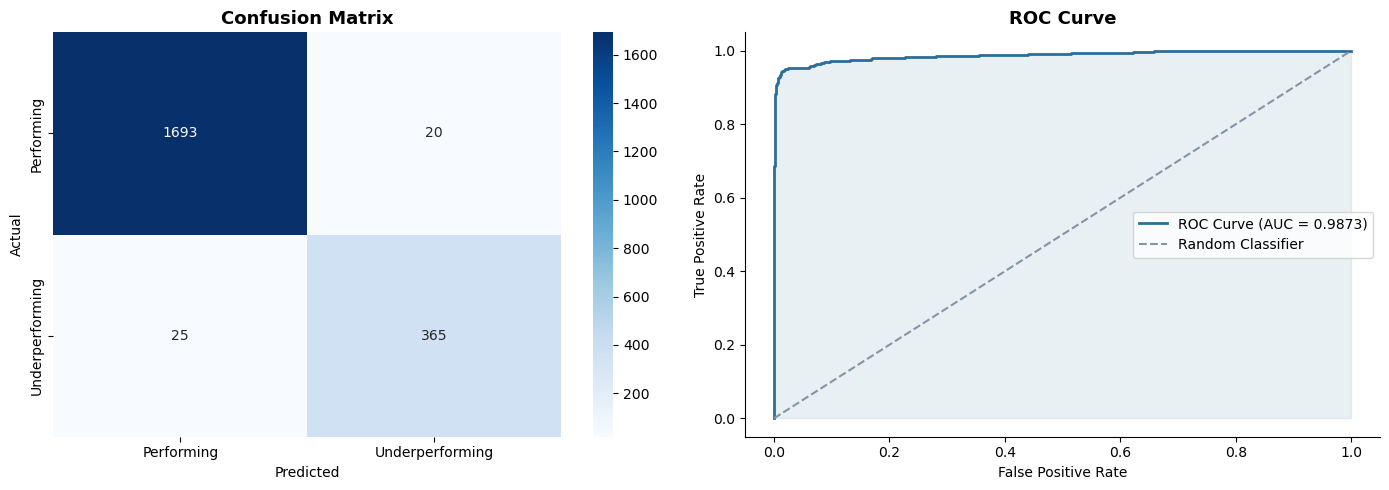

In [16]:
# ─────────────────────────────────────────────
# CONFUSION MATRIX
# ─────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Performing', 'Underperforming'],
    yticklabels=['Performing', 'Underperforming'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color=COLORS['primary'],
             linewidth=2,
             label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})')
axes[1].plot([0, 1], [0, 1], color=COLORS['muted'],
             linestyle='--', linewidth=1.5,
             label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1,
                     color=COLORS['primary'])
axes[1].set_title('ROC Curve',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Model Evaluation Findings

- **98% accuracy and 0.987 ROC-AUC** — high performance confirmed 
  as legitimate, not leakage
- **StockTurnover is the dominant predictor at 75.6% importance** — 
  products where purchases significantly exceeded sales are at highest 
  risk of underperformance. This is a strong and interpretable business rule
- **AvgUnitsSoldPerDay contributes 11.1%** — slow moving products 
  are the second strongest risk indicator
- **Cluster contributes only 0.03%** — the unsupervised clustering 
  added minimal predictive value here, but was valuable for segment 
  discovery and business interpretation
- **94% recall on Underperforming class** — the model correctly 
  identifies 94% of actual underperforming products, missing only 6%
- **95% precision on Underperforming class** — when the model flags 
  a product as underperforming it is correct 95% of the time
- **Business implication:** Stock turnover monitoring is the single 
  most actionable early warning signal for underperformance risk

## 4. Export Predictions to CSV & SQLite

Adding cluster labels and underperformance risk predictions back 
to the master dataset so Power BI can use them for predictive 
visualizations.

In [17]:
# ─────────────────────────────────────────────
# ADD PREDICTIONS TO MASTER DATASET
# ─────────────────────────────────────────────

# Get predictions for full dataset
X_full      = ml_df[RF_FEATURES_CLEAN].copy()
ml_df['PredictedUnderperforming'] = rf_model_clean.predict(X_full)
ml_df['UnderperformingRiskScore'] = rf_model_clean.predict_proba(X_full)[:, 1]

# Round risk score to 4 decimal places
ml_df['UnderperformingRiskScore'] = ml_df['UnderperformingRiskScore'].round(4)

print("Predictions added to dataset")
print(f"\nPrediction Distribution:")
print(f"  Predicted Performing     : {(ml_df['PredictedUnderperforming']==0).sum():,}")
print(f"  Predicted Underperforming: {(ml_df['PredictedUnderperforming']==1).sum():,}")

print(f"\nRisk Score Distribution:")
print(ml_df['UnderperformingRiskScore'].describe().round(4))

Predictions added to dataset

Prediction Distribution:
  Predicted Performing     : 8,554
  Predicted Underperforming: 1,960

Risk Score Distribution:
count    10514.0000
mean         0.2115
std          0.3607
min          0.0000
25%          0.0104
50%          0.0306
75%          0.1106
max          0.9997
Name: UnderperformingRiskScore, dtype: float64


In [18]:
# ─────────────────────────────────────────────
# MERGE BACK TO FULL VENDOR SUMMARY
# Add cluster labels and risk scores to the
# original df which has all 27 columns
# ─────────────────────────────────────────────

# Columns to add back
ml_cols = ml_df[['VendorName', 'Description',
                  'Cluster', 'ClusterLabel',
                  'PredictedUnderperforming',
                  'UnderperformingRiskScore']].copy()

# Merge on VendorName and Description
df_enriched = df.merge(ml_cols,
                        on  = ['VendorName', 'Description'],
                        how = 'left')

print(f"Original shape  : {df.shape}")
print(f"Enriched shape  : {df_enriched.shape}")
print(f"\nNew columns added:")
print([c for c in df_enriched.columns if c not in df.columns])

print(f"\nNull check on new columns:")
new_cols = ['Cluster', 'ClusterLabel',
            'PredictedUnderperforming', 'UnderperformingRiskScore']
print(df_enriched[new_cols].isnull().sum())

Original shape  : (10514, 27)
Enriched shape  : (13532, 31)

New columns added:
['Cluster', 'ClusterLabel', 'PredictedUnderperforming', 'UnderperformingRiskScore']

Null check on new columns:
Cluster                     0
ClusterLabel                0
PredictedUnderperforming    0
UnderperformingRiskScore    0
dtype: int64


In [19]:
# ─────────────────────────────────────────────
# SAVE ENRICHED DATASET
# 1. Back to SQLite as vendor_sales_summary_ml
# 2. New CSV for Power BI
# ─────────────────────────────────────────────
import os

conn = sqlite3.connect('../inventory.db')

# Save to SQLite
df_enriched.to_sql('vendor_sales_summary_ml',
                   conn, if_exists='replace', index=False)

# Save to CSV
os.makedirs('../outputs', exist_ok=True)
csv_path = '../outputs/vendor_sales_summary_ml.csv'
df_enriched.to_csv(csv_path, index=False)

conn.close()

print(f"Saved to SQLite: vendor_sales_summary_ml")
print(f"Saved to CSV   : {csv_path}")
print(f"Final shape    : {df_enriched.shape}")
print(f"Total columns  : {df_enriched.shape[1]}")

Saved to SQLite: vendor_sales_summary_ml
Saved to CSV   : ../outputs/vendor_sales_summary_ml.csv
Final shape    : (13532, 31)
Total columns  : 31


In [20]:
# ─────────────────────────────────────────────
# INVESTIGATE DUPLICATES
# ─────────────────────────────────────────────

# Check for duplicates in ml_cols
dupes = ml_cols.duplicated(subset=['VendorName', 'Description']).sum()
print(f"Duplicate VendorName+Description in ml_cols: {dupes:,}")

# Check for duplicates in original df
dupes_df = df.duplicated(subset=['VendorName', 'Description']).sum()
print(f"Duplicate VendorName+Description in df: {dupes_df:,}")

Duplicate VendorName+Description in ml_cols: 1,006
Duplicate VendorName+Description in df: 1,006


In [21]:
# ─────────────────────────────────────────────
# FIX MERGE — USE INDEX INSTEAD OF NAME/DESC
# ─────────────────────────────────────────────

# Reset index on original df to get a clean key
df_enriched = df.copy()
df_enriched['Cluster']                   = ml_df['Cluster'].values
df_enriched['ClusterLabel']              = ml_df['ClusterLabel'].values
df_enriched['PredictedUnderperforming']  = ml_df['PredictedUnderperforming'].values
df_enriched['UnderperformingRiskScore']  = ml_df['UnderperformingRiskScore'].values

print(f"Original shape  : {df.shape}")
print(f"Enriched shape  : {df_enriched.shape}")
print(f"\nNull check on new columns:")
new_cols = ['Cluster', 'ClusterLabel',
            'PredictedUnderperforming',
            'UnderperformingRiskScore']
print(df_enriched[new_cols].isnull().sum())

Original shape  : (10514, 27)
Enriched shape  : (10514, 31)

Null check on new columns:
Cluster                     0
ClusterLabel                0
PredictedUnderperforming    0
UnderperformingRiskScore    0
dtype: int64


In [22]:
# ─────────────────────────────────────────────
# SAVE ENRICHED DATASET
# 1. Back to SQLite as vendor_sales_summary_ml
# 2. New CSV for Power BI
# ─────────────────────────────────────────────
import os

conn = sqlite3.connect('../inventory.db')

# Save to SQLite
df_enriched.to_sql('vendor_sales_summary_ml',
                   conn, if_exists='replace', index=False)

# Save to CSV
os.makedirs('../outputs', exist_ok=True)
csv_path = '../outputs/vendor_sales_summary_ml.csv'
df_enriched.to_csv(csv_path, index=False)

conn.close()

print(f"Saved to SQLite : vendor_sales_summary_ml")
print(f"Saved to CSV    : {csv_path}")
print(f"Final shape     : {df_enriched.shape}")
print(f"Total columns   : {df_enriched.shape[1]}")

Saved to SQLite : vendor_sales_summary_ml
Saved to CSV    : ../outputs/vendor_sales_summary_ml.csv
Final shape     : (10514, 31)
Total columns   : 31


In [25]:
# ─────────────────────────────────────────────
# CLOSE & SUMMARY
# ─────────────────────────────────────────────

print("=" * 55)
print("ML PIPELINE COMPLETE")
print("=" * 55)
print(f"\nModels Built:")
print(f"  1. K-Means Clustering    — k=4 segments identified")
print(f"  2. Random Forest         — 98% accuracy, 0.987 AUC")
print(f"\nKey Finding:")
print(f"  StockTurnover is the #1 predictor of underperformance")
print(f"  at 75.6% feature importance")
print(f"\nOutputs Saved:")
print(f"  SQLite : vendor_sales_summary_ml (10,514 rows, 31 cols)")
print(f"  CSV    : outputs/vendor_sales_summary_ml.csv")
print(f"\nNext Step: Update Power BI to use enriched CSV")
print("=" * 55)


ML PIPELINE COMPLETE

Models Built:
  1. K-Means Clustering    — k=4 segments identified
  2. Random Forest         — 98% accuracy, 0.987 AUC

Key Finding:
  StockTurnover is the #1 predictor of underperformance
  at 75.6% feature importance

Outputs Saved:
  SQLite : vendor_sales_summary_ml (10,514 rows, 31 cols)
  CSV    : outputs/vendor_sales_summary_ml.csv

Next Step: Update Power BI to use enriched CSV
